# 고객 가치 × 이탈 위험 세그먼테이션
DAY 655 이전 행동으로 고객가치를 계산하고 이후 56일 이탈 여부로 위험 기준을 검증합니다.

- 고객가치: Frequency·Monetary(FM) 사분위 점수
- 이탈 위험: 개인별 중앙 구매 간격 대비 최근 구매 지연 비율
- 목표: 우선 방어할 고가치 이탈 위험 고객 식별

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_DIR / "data" / "processed" / "customer_features.csv"
OUTPUT_PATH = PROJECT_DIR / "data" / "processed" / "customer_segments.csv"
customers = pd.read_csv(DATA_PATH)
print(f"고객 수: {len(customers):,}")
display(customers.head())
display(customers.isna().sum().to_frame("missing").query("missing > 0"))

고객 수: 2,499


,household_key,first_day,last_day,active_days,baskets,revenue,items,total_discount,unique_products,unique_stores,median_gap_days,mean_gap_days,p75_gap_days,recency_at_cutoff,avg_basket_value,discount_to_sales_ratio,recency_to_gap_ratio,churn_56d_label,risk_rule_1_5x_gap
0,1,51,649,72,78,3869.70000,1807,747.62,616,2,9.0,8.422535,11.0,6,49.611538,0.161916,0.666667,0,0
1,2,103,622,44,44,1823.45000,763,327.96,510,5,7.0,12.069767,14.5,33,41.442044,0.152440,4.714286,0,1
2,3,113,640,44,45,2594.30000,8503,739.65,497,3,9.0,12.255814,15.0,15,57.651112,0.221854,1.666667,0,1
3,4,104,627,30,30,1200.11000,382,118.15,164,6,13.0,18.034483,21.0,28,40.003666,0.089626,2.153846,1,1
4,5,85,589,31,38,749.08997,242,118.33,196,2,14.0,16.800000,20.0,66,19.712894,0.136416,4.714286,0,1


,missing
median_gap_days,9
mean_gap_days,9
p75_gap_days,9
recency_to_gap_ratio,9


## 1. 변수 분포 확인

,count,mean,std,min,25%,50%,75%,90%,95%,max
recency_at_cutoff,2499.0,26.556222,68.136122,0.000000,1.000000,5.000000,19.000000,61.200000,125.000000,625.000000
baskets,2499.0,101.494998,107.452622,1.000000,35.000000,72.000000,131.000000,214.000000,295.100000,1210.000000
revenue,2499.0,2931.247956,3067.125407,4.490000,857.265000,1963.050000,4007.379950,6862.020000,8869.793000,33970.168000
avg_basket_value,2499.0,31.373718,19.109368,2.531379,18.047687,27.111765,40.376364,55.281204,67.736901,168.853655
discount_to_sales_ratio,2499.0,0.157148,0.054508,0.000000,0.120211,0.151840,0.186387,0.225702,0.253812,0.430294
median_gap_days,2490.0,10.639357,21.144784,1.000000,4.000000,6.000000,10.000000,19.500000,29.000000,333.000000
recency_to_gap_ratio,2490.0,3.219524,10.277692,0.000000,0.250000,0.875000,2.285714,6.000000,13.156073,193.000000


/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_26417/2920149047.py:6: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_26417/2920149047.py:6: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_26417/2920149047.py:6: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_26417/2920149047.py:6: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_26417/2920149047.py:6: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch17

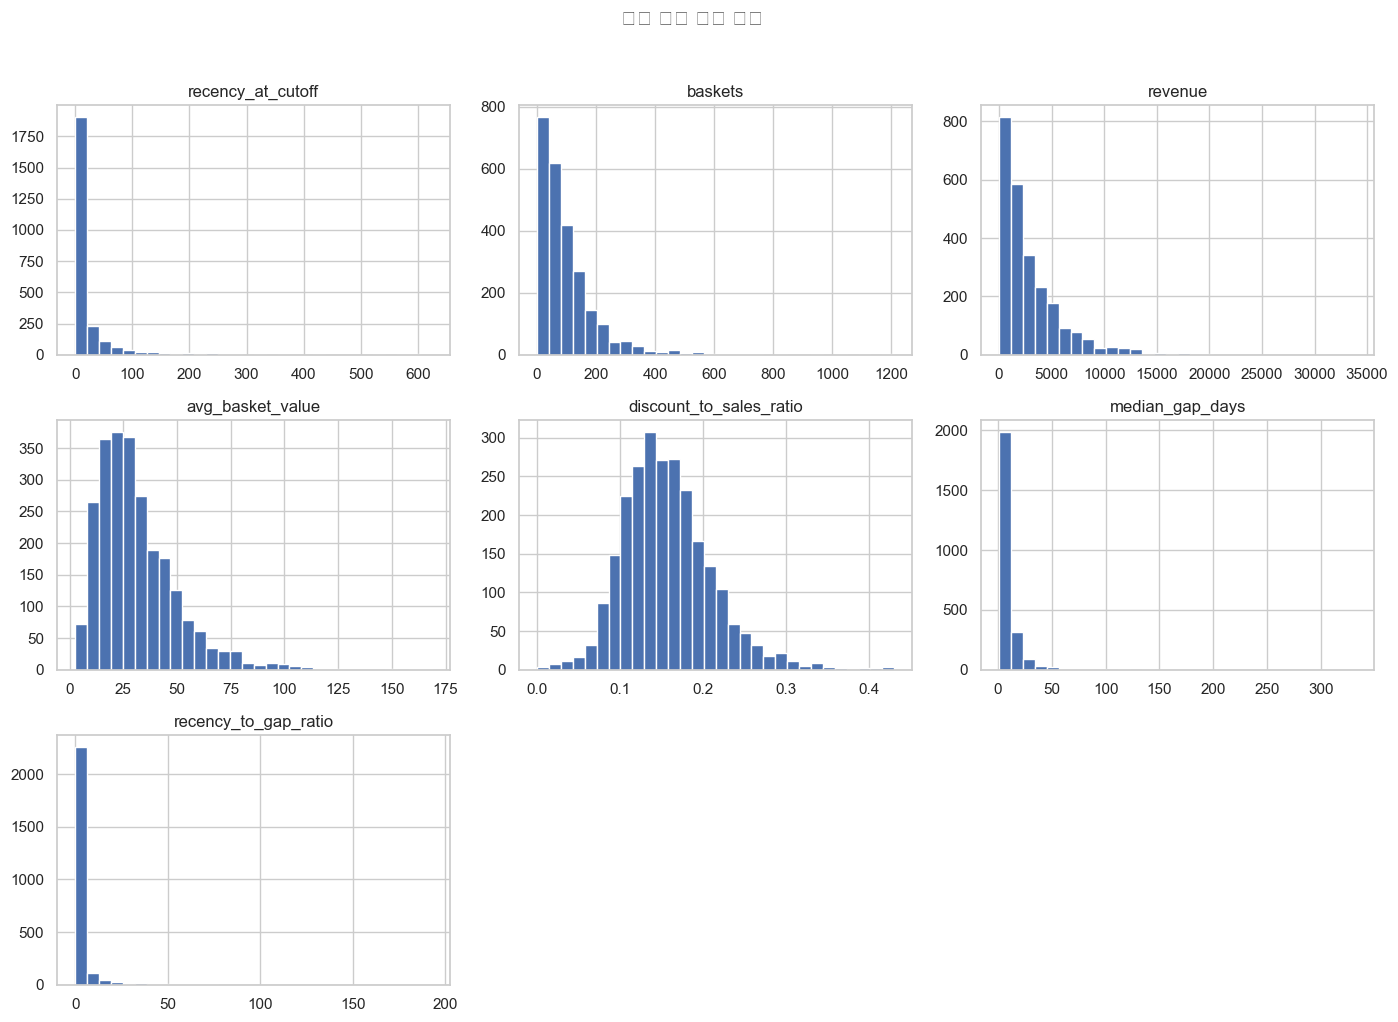

In [2]:
analysis_columns = ["recency_at_cutoff", "baskets", "revenue", "avg_basket_value",
                    "discount_to_sales_ratio", "median_gap_days", "recency_to_gap_ratio"]
display(customers[analysis_columns].describe(percentiles=[.25, .5, .75, .9, .95]).T)
customers[analysis_columns].hist(figsize=(14, 10), bins=30)
plt.suptitle("고객 행동 변수 분포", y=1.02, fontsize=15)
plt.tight_layout(); plt.show()

## 2. FM 기반 고객가치
Recency는 이탈 위험에서 별도로 사용하므로 고객가치에는 Frequency와 Monetary만 반영합니다. 이렇게 해야 최근성 정보가 가치와 위험 양쪽에 중복 반영되지 않습니다.

In [3]:
customers["r_score"] = pd.qcut(customers["recency_at_cutoff"].rank(method="first"), 4, labels=[4,3,2,1]).astype(int)
customers["f_score"] = pd.qcut(customers["baskets"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
customers["m_score"] = pd.qcut(customers["revenue"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
customers["fm_value_score"] = customers[["f_score","m_score"]].sum(axis=1)
customers["value_group"] = pd.cut(customers["fm_value_score"], [1,3,6,8], labels=["Low","Medium","High"])
display(customers["value_group"].value_counts(sort=False).to_frame("customers"))

,customers
value_group,
Low,747
Medium,1003
High,749


## 3. 이탈 위험 임계값 검증
Precision은 위험군의 적중률, Recall은 실제 이탈 고객의 포착률입니다.

In [4]:
results = []
actual = customers["churn_56d_label"].eq(1)
for threshold in [1.0, 1.5, 2.0, 3.0]:
    predicted = (customers["recency_to_gap_ratio"] >= threshold) & (customers["recency_at_cutoff"] >= 14)
    tp, fp, fn = (predicted & actual).sum(), (predicted & ~actual).sum(), (~predicted & actual).sum()
    results.append({"threshold": threshold, "risk_customers": int(predicted.sum()),
                    "precision": tp/(tp+fp), "recall": tp/(tp+fn)})
threshold_table = pd.DataFrame(results)
display(threshold_table.style.format({"precision": "{:.1%}", "recall": "{:.1%}"}))

,threshold,risk_customers,precision,recall
0,1.000000,720,26.7%,67.6%
1,1.500000,647,27.2%,62.0%
2,2.000000,585,27.9%,57.4%
3,3.000000,443,32.1%,50.0%


## 4. 최종 세그먼트
1.5배를 위험, 3배를 고위험 기준으로 사용합니다. 구매 간격이 없는 고객은 판단 보류입니다.

FM(Frequency랑 Monetary) - 사분위로 나누어 1~4점으로 부여하고 고객가치를 판단함
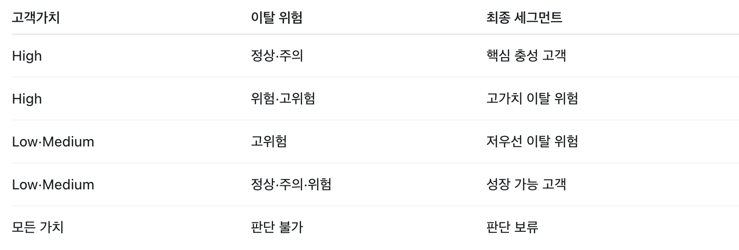

In [5]:
customers["risk_group"] = pd.cut(customers["recency_to_gap_ratio"], [-np.inf,1,1.5,3,np.inf],
                                      labels=["정상","주의","위험","고위험"])
customers["risk_group"] = customers["risk_group"].cat.add_categories(["판단 보류"]).fillna("판단 보류")

def assign_segment(row):
    value, risk = row["value_group"], row["risk_group"]
    if risk == "판단 보류": return "판단 보류"
    if value == "High" and risk in ["위험","고위험"]: return "고가치 이탈 위험"
    if value == "High": return "핵심 충성 고객"
    if risk == "고위험": return "저우선 이탈 위험"
    return "성장 가능 고객"

customers["segment"] = customers.apply(assign_segment, axis=1)
display(customers["segment"].value_counts().to_frame("customers"))

,customers
segment,
성장 가능 고객,1354
핵심 충성 고객,581
저우선 이탈 위험,387
고가치 이탈 위험,168
판단 보류,9


## 5. 세그먼트 프로파일 및 타당성 검증

,customers,avg_revenue,avg_baskets,avg_recency,avg_gap_ratio,actual_churn_rate
segment,,,,,,
핵심 충성 고객,581,"6,492.6",213.0,1.5,0.45,0.0%
고가치 이탈 위험,168,"5,837.0",203.0,19.0,8.06,10.7%
성장 가능 고객,1354,"1,575.9",57.0,12.4,0.90,10.0%
저우선 이탈 위험,387,"1,132.5",47.8,104.3,13.40,32.8%
판단 보류,9,36.3,1.2,573.6,nan,33.3%


/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_26417/2487406950.py:15: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) Arial.
  plt.title("고객가치와 구매주기 기반 이탈 위험"); plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_26417/2487406950.py:15: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) Arial.
  plt.title("고객가치와 구매주기 기반 이탈 위험"); plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_26417/2487406950.py:15: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Arial.
  plt.title("고객가치와 구매주기 기반 이탈 위험"); plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_26417/2487406950.py:15: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  plt.title("고객가치와 구매주기 기반 이탈 위험"); plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_26417/2487406950.py:15: User

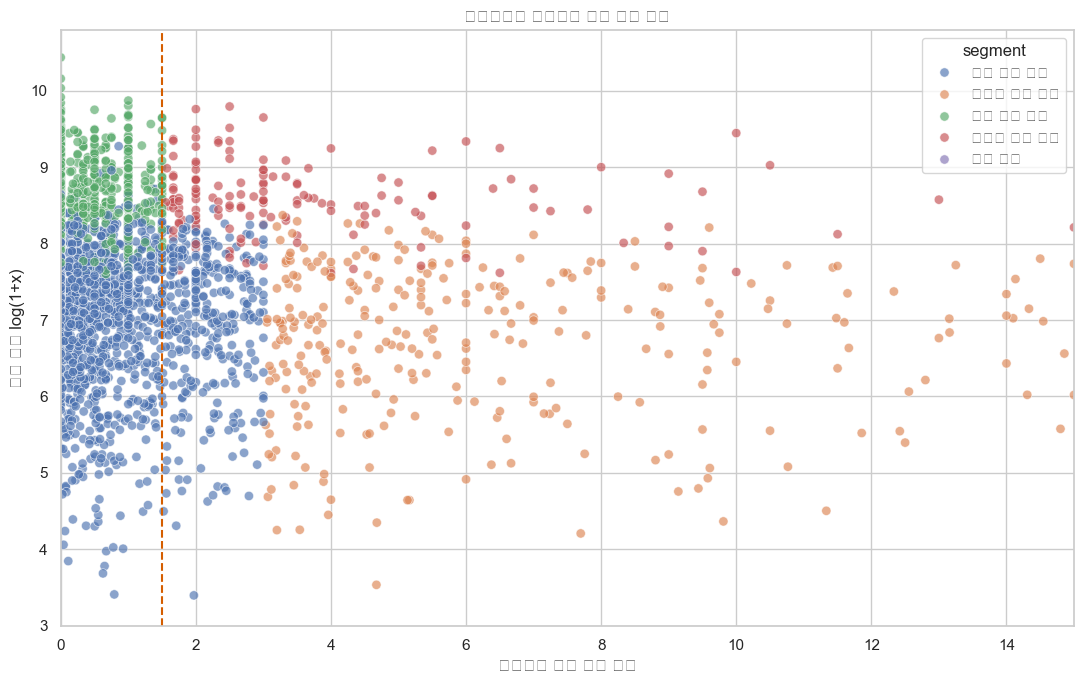

In [6]:
segment_summary = customers.groupby("segment").agg(
    customers=("household_key","nunique"), avg_revenue=("revenue","mean"),
    avg_baskets=("baskets","mean"), avg_recency=("recency_at_cutoff","mean"),
    avg_gap_ratio=("recency_to_gap_ratio","mean"), actual_churn_rate=("churn_56d_label","mean")
).sort_values("avg_revenue", ascending=False)
display(segment_summary.style.format({"avg_revenue":"{:,.1f}", "avg_baskets":"{:.1f}",
    "avg_recency":"{:.1f}", "avg_gap_ratio":"{:.2f}", "actual_churn_rate":"{:.1%}"}))

plot_data = customers.assign(log_revenue=np.log1p(customers["revenue"]))
plt.figure(figsize=(11,7))
sns.scatterplot(data=plot_data, x="recency_to_gap_ratio", y="log_revenue", hue="segment", alpha=.65, s=45)
plt.axvline(1.5, color="#D55E00", linestyle="--")
plt.xlim(0, min(15, plot_data["recency_to_gap_ratio"].quantile(.99)))
plt.xlabel("구매주기 대비 지연 비율"); plt.ylabel("누적 매출 log(1+x)")
plt.title("고객가치와 구매주기 기반 이탈 위험"); plt.tight_layout(); plt.show()

## 6. Tableau 및 후속 분석용 저장

In [7]:
customers.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"저장 완료: {OUTPUT_PATH}")
print(f"행 수: {len(customers):,}, 열 수: {customers.shape[1]}")

저장 완료: /Users/imsubeen/Desktop/YBIGTA/26-2/DA SUMMER2/data/processed/customer_segments.csv
행 수: 2,499, 열 수: 26
